# High-Resolution Image Synthesis with Latent Diffusion Models (LDMs)

In this tutorial, we will implement and train an **unconditional** [Latent Diffusion Model (LDM)](https://arxiv.org/abs/2112.10752) for high-resolution image synthesis using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) library, which is built on top of [PyTorch](https://pytorch.org/). All experiments in this tutorial were run on a consumer laptop with an Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM). The code is designed to be lightweight so it can run on modest hardware, at the cost of longer training times and lower image resolution compared to large-scale LDM setups. On GPUs with more memory, you can increase image resolution, model size, and batch size for better sample quality and faster convergence.
<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ldm.png" alt="UnCLIP overview" width="1000"/>
  <br>
  <em>An overview of the LDM pipeline, Rombach, et al. (2022)</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Perceptual Compression with a Variational Autoencoder (VAE)](#perceptual-compression-with-a-variational-autoencoder-vae)
- [Training an LDM Model](#training-an-ldm-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

here we will use the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/). images in this dataset are RGB with a shape of `(3, 96, 96)`.

In [1]:
# Import all necessary libraries and modules for training a DDPM model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.io import read_image
from torchvision.transforms import Resize, CenterCrop
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import glob
# import required classes from the DDIM module of TorchDiff
import torchdiff
# Import required classes from the LDM module of TorchDiff
from torchdiff.ldm import AutoencoderLDM, TrainAE, TrainLDM, SampleLDM
from torchdiff.ddpm import SchedulerDDPM, ReverseDDPM, ForwardDDPM
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import DiffusionNetwork, Metrics, mse_loss

In [2]:
print(torchdiff.__version__)

2.4.0


## Downloading the STL-10 Dataset from Torchvision

In this section, we will download the [STL-10](https://pytorch.org/vision/stable/generated/torchvision.datasets.STL10.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library.

In [3]:
transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform)

### Using a Subset of the STL-10 Dataset

here we will use a small subset of the STL-10 dataset (10000) for training both autoencoder and latent diffusion models.

In [4]:
# Use small subset
train_subset = Subset(train_dataset, torch.randperm(len(train_dataset))[:10000])
test_subset = Subset(test_dataset, torch.randperm(len(test_dataset))[:100])

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

### Visualizing Training Images

In [6]:
stl10_classes = ['airplane', 'bird', 'car', 'cat', 'deer', 
                 'dog', 'horse', 'monkey', 'ship', 'truck']

def denormalize(tensor):
    """Convert tensor from [-1, 1] back to [0, 1] for display"""
    return tensor * 0.5 + 0.5

def visualize_stl10_grid(dataloader, num_images=64):
    """
    Visualize STL-10 images in an 8x8 grid with labels
    """
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            break
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    
    fig, axes = plt.subplots(8, 8, figsize=(12, 12))
    fig.suptitle('STL-10 Dataset Sample (8x8 Grid)', fontsize=14)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)  
                img = torch.clamp(img, 0, 1)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{stl10_classes[all_labels[idx]]}', fontsize=10)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

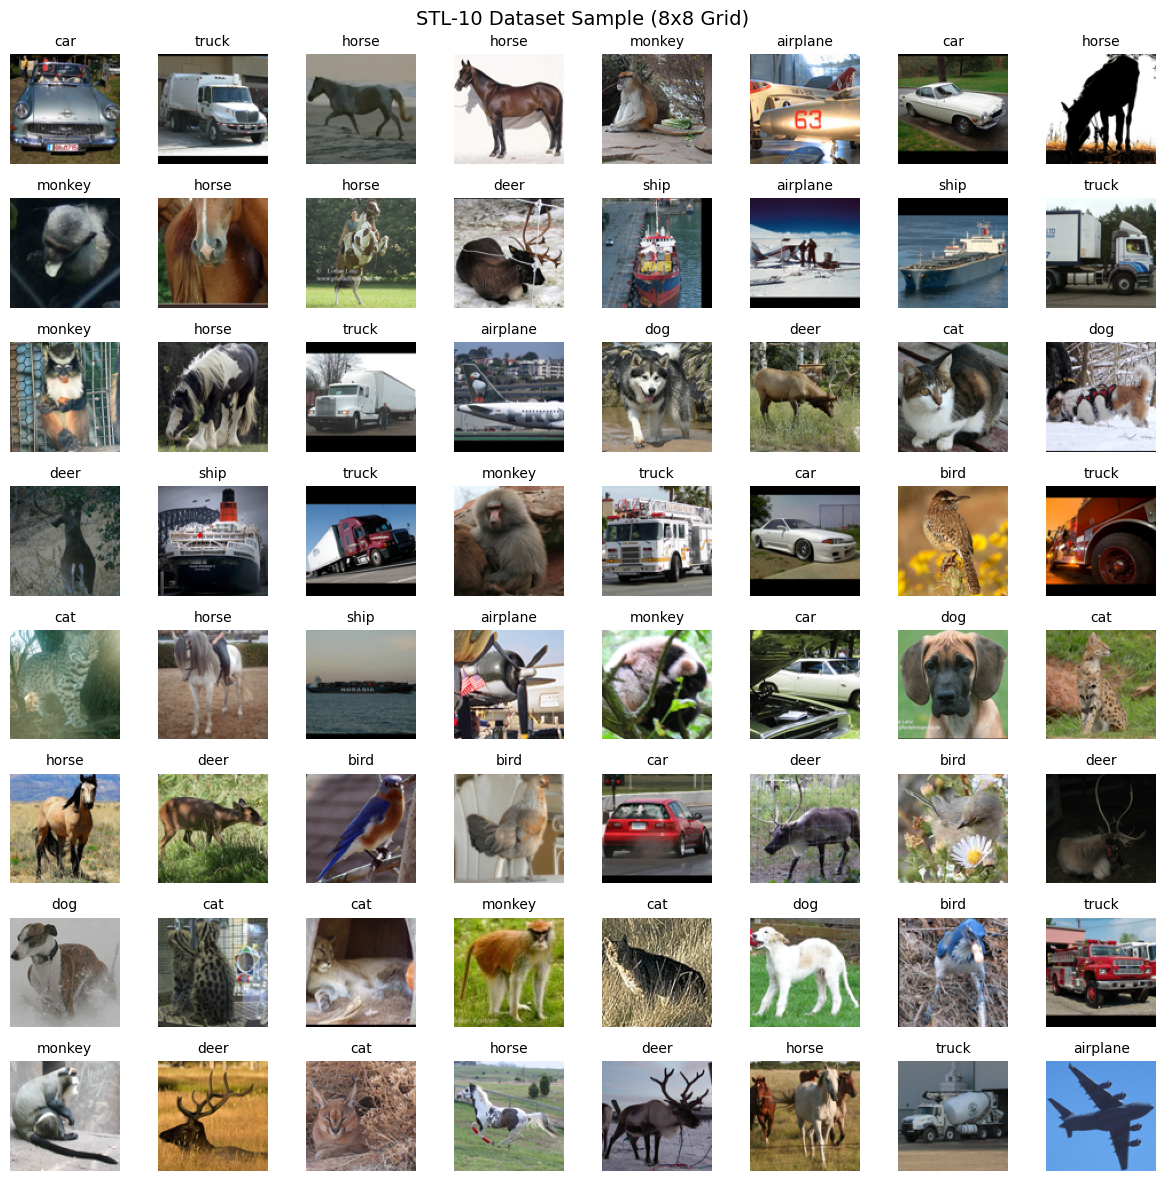

In [9]:
visualize_stl10_grid(train_loader, num_images=64)

## Perceptual Compression with a Variational Autoencoder (VAE)

we will use the same dataset to train both a compression model and a diffusion model in a compressed latent space. The specific VAE used in TorchDiff is [`torchdiff.ldm.AutoencoderLDM`](https://torchdiff.readthedocs.io/en/latest/ldm.html#torchdiff.ldm.AutoencoderLDM), which encodes images into a latent space and decodes them back to the image space. here the designed model below compresses images from `(3, 96, 96)` into a latent space of shape `(2, 24, 24)` and then decoded back to the original shape of `(3, 96, 96)`.

In [6]:
# train auto-encoder of ldm models
comp_net = AutoencoderLDM_(
    in_channels=3,
    down_channels=[64, 128],      # 2 down blocks
    up_channels=[128, 64],
    out_channels=3,
    dropout_rate=0.2,
    latent_channels=2,
    num_heads=4,
    num_groups=8,
    num_layers_per_block=6,
    total_down_sampling_factor=2,     # 2 blocks × stride 2 = factor 4 ✓
    use_flash=True,
    num_embeddings=256
)


comp_optim = torch.optim.Adam(comp_net.parameters(), lr=1e-5)
# loss function
comp_loss = nn.MSELoss()


vae_trainer = TrainAE_(
    model=comp_net,
    optim=comp_optim,
    train_loader=train_loader,
    max_epochs = 100,
    device="cuda",
    checkpoint = 10,
    warmup_steps = 300,
    kl_warmup_epochs = 5,
    patience = 100,
    use_ddp = False, # enable if using multiple GPUs
    grad_acc = 8,
    log_freq = 5,
    use_comp = False # disable model compilation (not required here)
)

In [7]:
# the code below finds out the shape of images in latent space 
x = torch.rand((1, 3, 96, 96)).to("cuda")
print(x.dtype)
print("original size: ", x.size())
z, loss = comp_net.encode(x)
rx = comp_net.decode(z)
print("latent space shape: ", z.size())
print("reconstracted shape: ", rx.size())
print("total model params: ", sum([p.numel() for p in comp_net.parameters()]))

torch.float32
original size:  torch.Size([1, 3, 96, 96])
latent space shape:  torch.Size([1, 2, 48, 48])
reconstracted shape:  torch.Size([1, 3, 96, 96])
total model params:  2927749


In [20]:
vae_losses = vae_trainer()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07193571..1.0708098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.056423903..0.87563264].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.033035994..1.1659619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08116555..1.0443966].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.083134174..0.9280493].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.10294822..1.0280389].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-

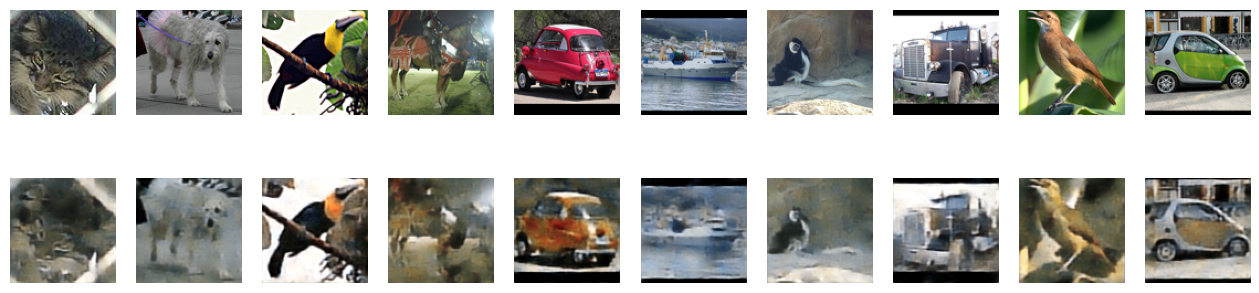

In [19]:
x, _ = next(iter(test_loader))
x = x.to('cuda')
comp_net.eval()
with torch.no_grad():
    x_hat, _, _, _ = comp_net(x)

# Unnormalize for display
def unnorm(img):
    return img * 0.5 + 0.5

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    axes[0, i].imshow(unnorm(x[i]).permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(unnorm(x_hat[i]).permute(1, 2, 0).cpu().numpy())
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstruction')
plt.show()

## Training a Latent Diffusion Model (LDM)

After encoding data into the latent space, a diffusion model (e.g., DDPM, DDIM, or SDE) is trained in this latent space. In this tutorial, we use an SDE model as the diffusion model. Before training the SDE in the latent space, we need to prepare several key components required for the training process:


- **DiffusionNetwork ([torchdiff.utils.DiffusionNetwork](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.DiffusionNetwork))**: this is the main network of all fundamental diffusion models (ddpm, ddim and sde) available in TorchDiff library, which is used as noise/score/v/x0 predictor.
 
- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  to train this model we will use adamw oprimizer from pytorch API.

- **Loss Function ([torchdiff.utils.mse_loss](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.mse_loss))**: a simple mean squared error loss implementation which is available in TorchDiff's utils module.

In [21]:
diff_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

In [29]:
diff_net = DiffusionNetwork(
    in_channels = 2,  # single channel for grayscale images in the training data
    down_channels = [64, 128, 256],
    mid_channels = [256, 256], 
    up_channels = [256, 128, 64],
    down_sampling = [True, True],
    time_embed_dim = 256,
    y_embed_dim = 256,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 4,
    cont_time = False, # continuous time is used for SDE based model time sampling here no need to it
    use_flash_attention = True # if true automatically uses flash attention if available 
)

diff_optim = torch.optim.AdamW(
    [p for p in diff_net.parameters()], lr=1e-4
)
print(sum(p.numel() for p in diff_net.parameters()))

# here we use a cosine scheduler 
vs = SchedulerDDPM(schedule_type = "cosine")


fwd = ForwardDDPM(vs, pred_type = 'noise')
rwd = ReverseDDPM(vs, pred_type = 'noise')


diff_trainer = TrainLDM(
    diff_type = 'ddpm',
    fwd_diff = fwd,
    rwd_diff = rwd,
    diff_net = diff_net,
    comp_net = comp_net,
    optim = diff_optim,
    loss_fn = mse_loss,
    train_loader = diff_loader,
    max_epochs = 100,
    device = 'cuda',
    store_path = 'diff_train',
    patience = 200,
    warmup_steps = 200,
    norm_range = (-1.0, 1.0),
    norm_output = True,
    grad_acc = 4,
    log_freq = 5,
    time_eps = 1e-5,
    num_steps = 400
)

9435010


In [32]:
diff_losses = diff_trainer()

### Required TorchDiff DDPM Classes for Training

To train the DDPM model, this tutorial requires the following specific classes from the TorchDiff DDPM module:

- **DDPM Variance-Scheduler ([`torchdiff.ddpm.SchedulerDDPM`](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.SchedulerDDPM))**:
  This class manages the noise schedule for the DDPM model, defining parameters for the forward and reverse diffusion processes.
  
- **Reverse Diffusion ([`torchdiff.ddpm.ReverseDDPM`](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddpm.ReverseDDPM))**:
  This class handles the reverse diffusion process during sampling, enabling the generation of data from noise.

## Sampling from the Latent Diffusion Model (LDM)

In [40]:
# sampling process
sampler = SampleLDM(
    diff_type="ddpm",
    rwd_diff=rwd,
    diff_net=diff_net,
    comp_net=comp_net,
    num_steps = 1000,
    img_size=(96, 96),
    batch_size=20,
    in_channels=3,
    device="cuda",
    norm_range=(-1, 1)
)

In [41]:
gen_imgs = sampler(save_path="samples") # the created images will be stored in the given directory

Sampling: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:58<00:00, 17.17it/s]


### Visualizing Generated Images

In this section, we will visualize the images generated by the trained LDM model to inspect the results of the sampling process.

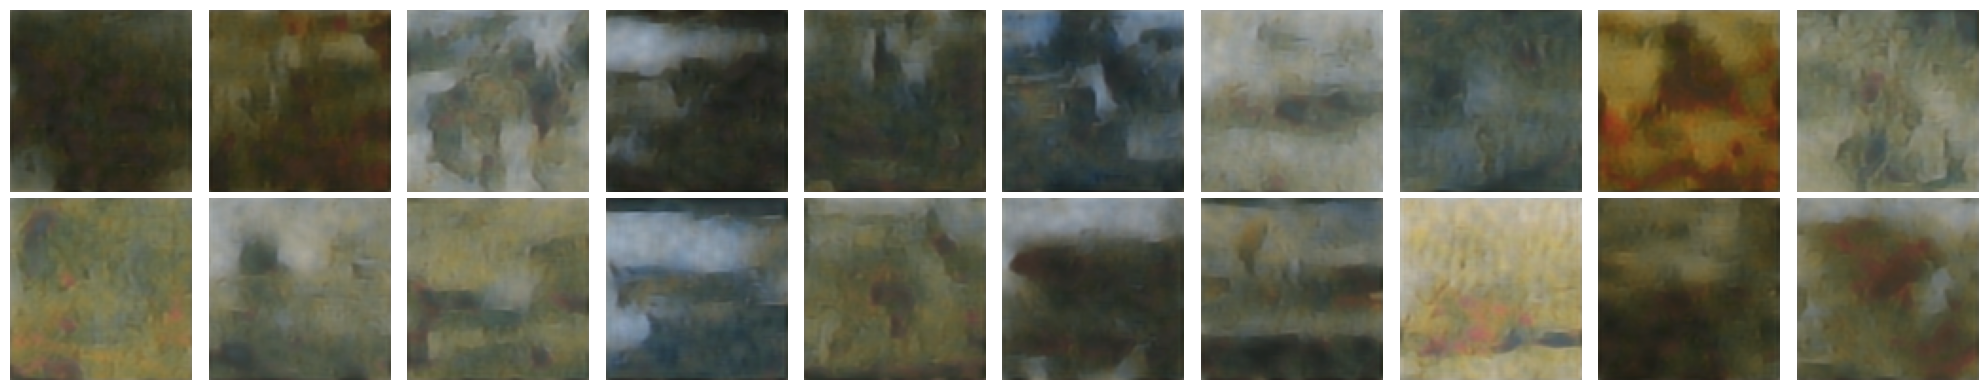

In [44]:
folder_path = "/home/loqman/Downloads/projs/TorchDiff/examples/ldm/samples"
num_images = 20 
rows, cols = 2, 10

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for i in range(num_images):
    img_path = os.path.join(folder_path, f"img_{i+1}.png")
    img = Image.open(img_path).convert('RGB') 

    ax = axes[i // cols, i % cols]
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Evaluating the Generated Images

The generated images are not of an optimal quality. there are some reasons for it. we trained the model on a proportion of the data (10K images), both autoencoder and also diffusion model in latent space are not converged as they should be (each for 100 epochs which is not enough, trainers are vanilla trainers and using techniques like EMA). both networks (vae and diffuion are shallower than they should be).

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Latent Diffusion Models and Their Implementation in TorchDiff](https://medium.com/@samaniloqman91/latent-diffusion-models-and-their-implementation-in-torchdiff-7dc04c33c4f7)
- [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752)